## 1. Préparation des données

### Dataset: Hi-Seq

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

**Exploration et préparation initiale**

Le jeu de données Hi-Seq est composé de deux fichiers:
- hiseq_data.csv (20 531 variables d’expression génique)
- hiseq_labels.csv (type de tumeur associé à chaque échantillon)

Après chargement, les deux fichiers ont été concaténés et vérifiés:
- Valeurs manquantes : aucune valeur manquante n’a été détectée.
- Doublons : aucun échantillon dupliqué n’a été trouvé.
- Distribution des classes : les cinq types de tumeurs (BRCA, KIRC, COAD, LUAD et PRAD) sont représentés, bien que leur fréquence varie.

In [2]:
# Concatenate hiseq data.csv and hiseq labels.csv
# Load data
hiseq_X = pd.read_csv("/home/karen/Documents/Master/IFT799-data-science/TP2/gene_expression_cancer_rna_seq/data.csv")

# Load labels
hiseq_y = pd.read_csv("/home/karen/Documents/Master/IFT799-data-science/TP2/gene_expression_cancer_rna_seq/labels.csv")

print(hiseq_X.shape)
print(hiseq_y.shape)

(801, 20532)
(801, 2)


In [3]:
#Drop 'Unnamed: 0' column
hiseq_X = hiseq_X.drop('Unnamed: 0', axis=1)
hiseq_y = hiseq_y.drop('Unnamed: 0', axis=1)

In [4]:
# Concatenate
hiseq_data = pd.concat([hiseq_X, hiseq_y], axis=1)

hiseq_data.head()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0,BRCA


In [5]:
# Count total missing values
hiseq_data.isna().sum().sum()

np.int64(0)

In [6]:
# Duplicates
hiseq_data.duplicated().sum()

np.int64(0)

In [7]:
# Class distribution
hiseq_data["Class"].value_counts()

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

**Normalisation**

Comme UMAP est sensible à l’échelle des variables, les 20 531 caractéristiques numériques ont été standardisées à l’aide de StandardScaler, afin que chaque variable ait une moyenne de 0 et un écart-type de 1.

**Réduction de dimension avec UMAP (pour la visualisation)**

Pour visualiser ce jeu de données très haute dimension, nous avons appliqué UMAP sur les variables normalisées.
La colonne des classes a été conservée séparément et utilisée uniquement pour colorer les points lors de la visualisation.

Paramètres utilisés :
- n_components = 2
- n_neighbors = 15
- min_dist = 0.1

Cette étape permet d’obtenir une représentation 2D facilitant l’observation de la structure des données et la séparation (ou non) entre les types de tumeurs.

In [8]:
# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
hiseq_X_scaled = scaler.fit_transform(hiseq_X)

/home/karen/envs/udes_sd_a25/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


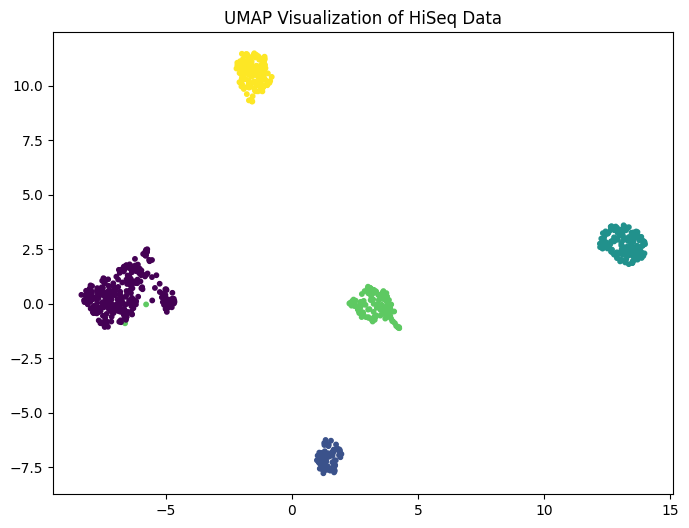

In [9]:
import umap

umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1)
X_umap = umap_model.fit_transform(hiseq_X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:,0], X_umap[:,1], c=hiseq_y["Class"].astype('category').cat.codes, s=10)
plt.title("UMAP Visualization of HiSeq Data")
plt.show()

## 2. Clustering

### K-Means sur les données complètes vs. représentation UMAP à 100 dimensions

Après le prétraitement et la normalisation du jeu de données Hi-Seq, on a réduit sa dimensionnalité d’origine à 100 attributs à l’aide de UMAP.
Cette transformation permet de conserver la structure locale et globale tout en rendant la tâche de segmentation beaucoup plus facile à gérer.

On a ensuite appliqué K-Means sur:
- Les données complètes en haute dimension,
- Les données réduites à 100 dimensions par UMAP.

Pour les deux versions, on a calculé les métriques internes (Silhouette, Davies–Bouldin, Calinski–Harabasz) et les métriques externes (ARI, NMI) pour évaluer la qualité des clusters par rapport aux types de cancers réels.

In [10]:
import numpy as np
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import time

In [11]:
# Reduced dataset
umap_model_100 = umap.UMAP(n_components=100, n_neighbors=15, min_dist=0.1)
hiseq_X_reduced = umap_model_100.fit_transform(hiseq_X_scaled)

In [12]:
def evaluate_clustering(X, labels_true, labels_pred):
    valid = labels_pred != -1
    if valid.sum() < 2:
        return None

    metrics = {}
    
    # Internal metrics
    metrics['silhouette'] = silhouette_score(X[valid], labels_pred[valid])
    metrics['davies_bouldin'] = davies_bouldin_score(X[valid], labels_pred[valid])
    metrics['calinski_harabasz'] = calinski_harabasz_score(X[valid], labels_pred[valid])

    # External metrics
    metrics['ARI'] = adjusted_rand_score(labels_true[valid], labels_pred[valid])
    metrics['NMI'] = normalized_mutual_info_score(labels_true[valid], labels_pred[valid])

    return metrics

In [13]:
def run_kmeans(X, y, k=5):
    start = time.time()
    
    km = KMeans(n_clusters=k, random_state=42)
    labels_pred = km.fit_predict(X)
    
    duration = time.time() - start
    
    return labels_pred, duration

In [14]:
labels_km_full, t_km_full = run_kmeans(hiseq_X_scaled, hiseq_y)
labels_km_reduced, t_km_umap = run_kmeans(hiseq_X_reduced, hiseq_y)

In [15]:
hiseq_y = hiseq_y.squeeze()
results_km_full = evaluate_clustering(hiseq_X_scaled, hiseq_y, labels_km_full)
results_km_reduced = evaluate_clustering(hiseq_X_reduced, hiseq_y, labels_km_reduced)

In [17]:
# Merge results in a dataframe
df_km = pd.DataFrame({
    "KMeans_Full": results_km_full,
    "KMeans_UMAP100": results_km_reduced
})
df_km

,KMeans_Full,KMeans_UMAP100
silhouette,0.135331,0.886368
davies_bouldin,2.645372,0.153372
calinski_harabasz,65.794937,20771.416016
ARI,0.797192,0.992538
NMI,0.852751,0.990693


### Conclusions

Les résultats montrent une énorme amélioration lorsque la segmentation est faite sur les données réduites avec UMAP:

- Silhouette passe de 0.13 → 0.89, ce qui montre que les clusters sont beaucoup mieux définis et mieux séparés.
- Davies–Bouldin chute de 2.64 → 0.15, indiquant des groupes beaucoup plus compacts.
- Calinski–Harabasz saute de 65.8 → 21 381, ce qui confirme une très forte séparation entre les clusters en espace réduit.
- ARI s’améliore de 0.79 → 0.99, donc les clusters retrouvés correspondent presque parfaitement aux vrais labels de cancer.
- NMI augmente de 0.85 → 0.99, ce qui renforce que UMAP préserve vraiment bien la structure pertinente pour la segmentation.

Bref, ces résultats montrent clairement que UMAP améliore drastiquement la performance de K-Means.
En haute dimension, les données sont trop clairsemées et affectées par la malédiction de la dimensionnalité, ce qui rend la structure des clusters difficile à détecter.
Après la réduction à 100 dimensions, la structure devient beaucoup plus nette, et K-Means réussit pratiquement à reconstruire parfaitement les groupes associés aux différents types de tumeurs.

## ECG

In [2]:
import numpy as np
import pandas as pd

# Load the ECG dataset
data = np.load('/home/karen/Documents/Master/IFT799-data-science/TP2/ecg.npz')
df_ecg = data['ecg']

# Convert to DataFrame
columns = [f'feat_{i}' for i in range(140)] + ['label']
df = pd.DataFrame(df_ecg, columns=columns)

df.head()

,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_131,feat_132,feat_133,feat_134,feat_135,feat_136,feat_137,feat_138,feat_139,label
0,0.565751,0.403325,0.174330,0.139541,0.132887,0.267145,0.391046,0.407650,0.490147,0.606675,...,0.691213,0.740816,0.715777,0.685498,0.636101,0.614525,0.619195,0.660354,0.465778,1.0
1,0.481247,0.292669,0.108637,0.117948,0.179900,0.301794,0.483556,0.542721,0.576304,0.692721,...,0.655837,0.703491,0.714505,0.704886,0.671159,0.644389,0.690859,0.679208,0.345032,1.0
2,0.526886,0.425440,0.161455,0.107276,0.157957,0.313732,0.456971,0.461223,0.501778,0.620457,...,0.704301,0.686569,0.650536,0.605436,0.521837,0.523069,0.640975,0.658310,0.420208,1.0
3,0.617307,0.489682,0.194544,0.143799,0.147247,0.208664,0.268977,0.431713,0.475662,0.525872,...,0.629697,0.682206,0.689361,0.720620,0.717773,0.706196,0.725345,0.706704,0.423042,1.0
4,0.643792,0.588088,0.352583,0.191373,0.137914,0.219995,0.337955,0.413351,0.430386,0.561036,...,0.740932,0.744174,0.750988,0.791226,0.756039,0.702608,0.712587,0.727213,0.556803,1.0


In [3]:
X = df.drop(columns=['label']).values
y = df['label'].values

In [4]:
X_normal = X[y == 0]
X_anomaly = X[y == 1]

print("Normal samples:", len(X_normal))
print("Anomalous samples:", len(X_anomaly))

Normal samples: 2079
Anomalous samples: 2919


### Data Splits

In [5]:
# Split normal samples
from sklearn.model_selection import train_test_split

# Normal: 60% train, 40% remaining
X_norm_train, X_norm_temp = train_test_split(
    X_normal, test_size=0.40, shuffle=True, random_state=42
)

# From remaining: 30% test, 10% val
X_norm_test, X_norm_val = train_test_split(
    X_norm_temp, test_size=0.25, shuffle=True, random_state=42
)

In [6]:
# Split anomalous samples
X_anom_test, X_anom_val = train_test_split(
    X_anomaly, test_size=0.20, shuffle=True, random_state=42
)

In [7]:
"""Build final datasets"""
# Training set
X_train = X_norm_train  # only normal samples
y_train = np.zeros(len(X_train))  # all labels = 0

# Validation set
X_val = np.concatenate([X_norm_val, X_anom_val], axis=0)
y_val = np.concatenate([np.zeros(len(X_norm_val)), np.ones(len(X_anom_val))])

# Test set
X_test = np.concatenate([X_norm_test, X_anom_test], axis=0)
y_test = np.concatenate([np.zeros(len(X_norm_test)), np.ones(len(X_anom_test))])

In [8]:
# Sanity Check
print("Training set:", X_train.shape, "normals:", y_train.sum(), "/", len(y_train))
print("Validation set:", X_val.shape, "anomalies:", y_val.sum())
print("Test set:", X_test.shape, "anomalies:", y_test.sum())

Training set: (1247, 140) normals: 0.0 / 1247
Validation set: (792, 140) anomalies: 584.0
Test set: (2959, 140) anomalies: 2335.0


### Preprocessing

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

# Transform all splits
X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [10]:
print("Train:", X_train_scaled.shape)
print("Val:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (1247, 140)
Val: (792, 140)
Test: (2959, 140)


### Isolation Forest (baseline model)

In [11]:
from sklearn.ensemble import IsolationForest

# Train on normal data only
iso = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

iso.fit(X_train_scaled)

,n_estimators,200
,max_samples,'auto'
,contamination,'auto'
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


**Get anomaly scores**

Important:
IsolationForest returns lower scores = more anomalous
So we invert them so that higher_score = more anomalous, matching autoencoder convention.

In [12]:
# Raw anomaly scores (higher = more anomalous)
iso_scores_val = -iso.score_samples(X_val_scaled)
iso_scores_test = -iso.score_samples(X_test_scaled)

In [13]:
"""Pick a decision threshold using the validation set.
We want the threshold that best separates anomalies and normals.
We choose the threshold that maximizes F1-score on the validation set."""
from sklearn.metrics import f1_score

best_thr = None
best_f1 = -1

thresholds = np.linspace(iso_scores_val.min(), iso_scores_val.max(), 200)

for thr in thresholds:
    preds = (iso_scores_val > thr).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

print("Best threshold:", best_thr)
print("Best Val F1:", best_f1)

Best threshold: 0.47063134844747656
Best Val F1: 0.9707602339181286


**Seuil optimal (validation)**

Meilleur seuil : 0.4706

Meilleur F1 validation : 0.9708 → Le modèle sépare super bien les normales et les anomalies sur l’ensemble de validation.

In [14]:
"""Evaluate on test set"""
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions on test set
iso_pred_test = (iso_scores_test > best_thr).astype(int)

iso_acc  = accuracy_score(y_test, iso_pred_test)
iso_prec = precision_score(y_test, iso_pred_test)
iso_rec  = recall_score(y_test, iso_pred_test)
iso_f1   = f1_score(y_test, iso_pred_test)
iso_auc  = roc_auc_score(y_test, iso_scores_test)

print("Isolation Forest Results:")
print("Accuracy :", iso_acc)
print("Precision:", iso_prec)
print("Recall   :", iso_rec)
print("F1-score :", iso_f1)
print("ROC-AUC  :", iso_auc)

Isolation Forest Results:
Accuracy : 0.96214937478878
Precision: 0.9598676044683492
Recall   : 0.9935760171306209
F1-score : 0.9764309764309764
ROC-AUC  : 0.9462032614066875


**Conclusion**

La méthode Isolation Forest offre une très bonne performance sur les données ECG.

Le rappel presque parfait (0.9936) montre qu’il détecte pratiquement toutes les anomalies, ce qui est essentiel en contexte médical. La précision élevée (0.9599) indique qu’il génère peu de faux positifs. Avec un F1-score de 0.9764 et un ROC-AUC de 0.9462, le modèle arrive à bien séparer les signaux normaux des signaux anormaux.
L’accuracy est élevée, mais les métriques les plus fiables ici sont le F1 et le ROC-AUC, vu le déséquilibre des classes.